In [1]:
# Cell 1: Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import zipfile
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve)

# For hyperparameter tuning
from scipy.stats import uniform, randint

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2: Create directory for saving figures
figures_dir = '/kaggle/working/figures'  # Path inside Kaggle environment
# figures_dir = 'figures'  # Uncomment this line if running locally

if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Folder '{figures_dir}' created successfully!")
else:
    print(f"Folder '{figures_dir}' already exists.")
    

Folder '/kaggle/working/figures' created successfully!


In [3]:
# Cell 3: Load the Heart Disease dataset using ucimlrepo (official UCI method)
# Install the package if not already installed
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

# Fetch dataset using correct ID (45 for Heart Disease)
heart_disease = fetch_ucirepo(id=45)

# Data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine features and target into one DataFrame
df = pd.concat([X, y], axis=1)

# Rename the target column (last column)
df.rename(columns={df.columns[-1]: 'target'}, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")


Dataset shape: (303, 14)

First 5 rows:

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

=== Missing Values ===
      Missing  Percentage
ca          4    1.320132
thal        2    0.660066

=== Target Distribution (Binary) ===
target
0    164
1    139
Name: count, dtype: int64
Percent

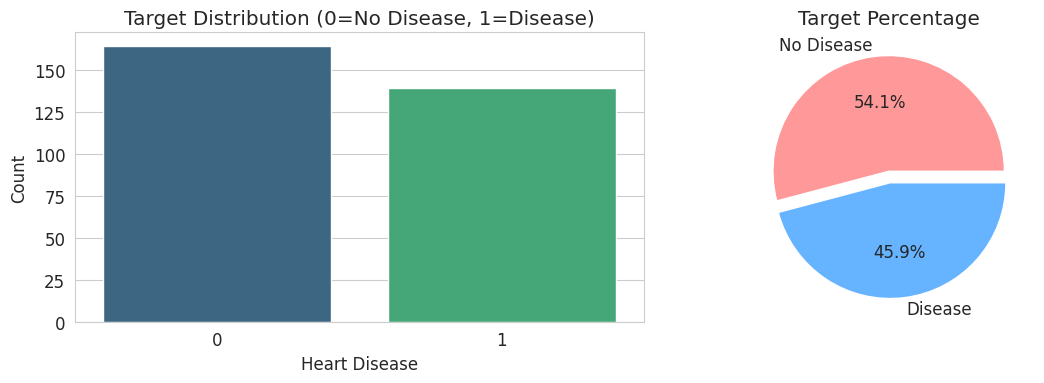

In [4]:
# Cell 4: Basic info and missing values analysis with figure saving
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print("\n=== Target Distribution (Binary) ===")
# Convert to binary: 0 = no disease, 1-4 = disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
target_counts = df['target'].value_counts()
print(target_counts)
print(f"Percentage with heart disease: {target_counts[1]/len(df)*100:.2f}%")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='target', ax=axes[0], palette='viridis')
axes[0].set_title('Target Distribution (0=No Disease, 1=Disease)')
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%', 
            colors=['#ff9999','#66b3ff'], explode=(0.05, 0.05))
axes[1].set_title('Target Percentage')
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'target_distribution.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

=== Statistical Summary ===
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   

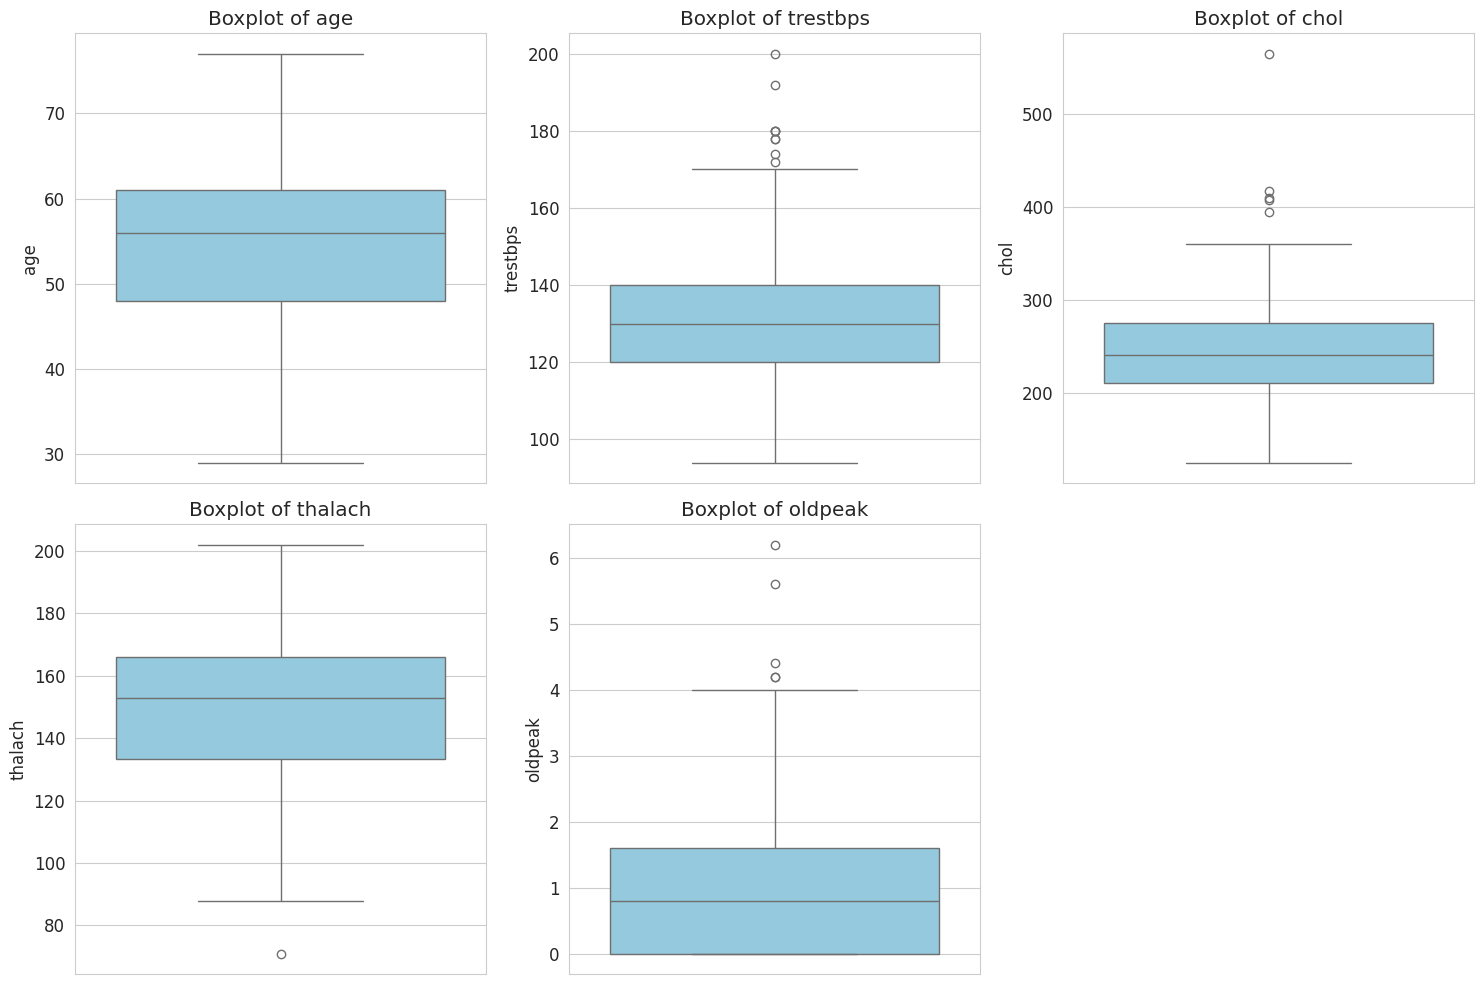

In [5]:
# Cell 5: Statistical summary and outlier visualization with figure saving
print("=== Statistical Summary ===")
print(df.describe())

# Visualize outliers using boxplots for numerical features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    
    # Calculate outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

# Remove the last empty subplot if any
if len(numerical_cols) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'outlier_boxplots.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

Figure saved to: /kaggle/working/figures/correlation_matrix.png


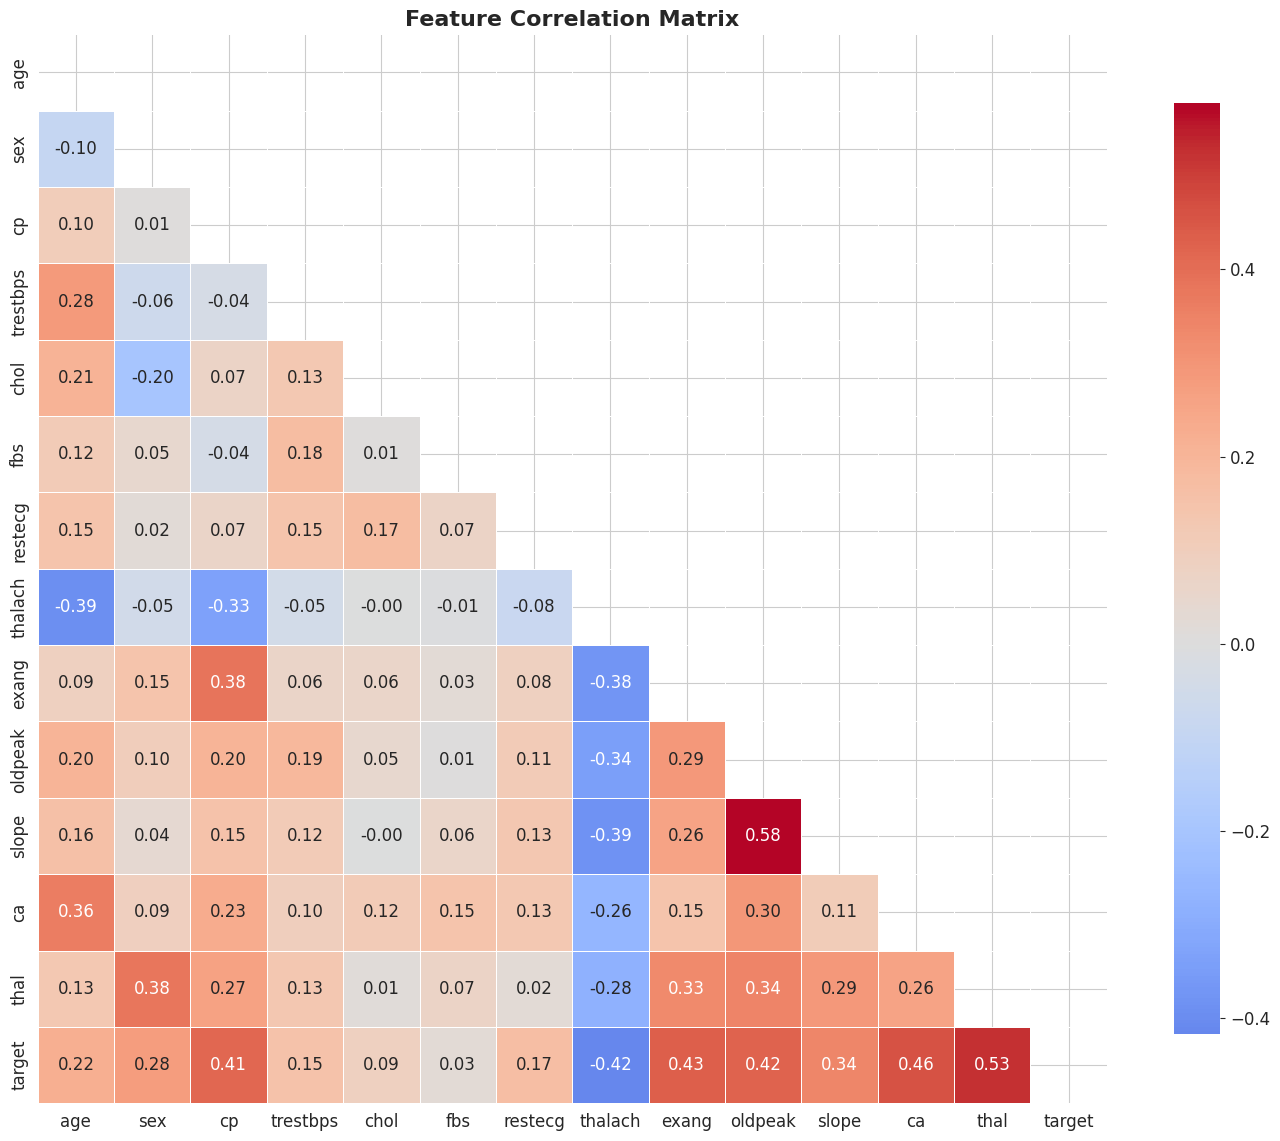


=== Features Correlated with Target ===
target      1.000000
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64
Figure saved to: /kaggle/working/figures/pairplot_top_features.png


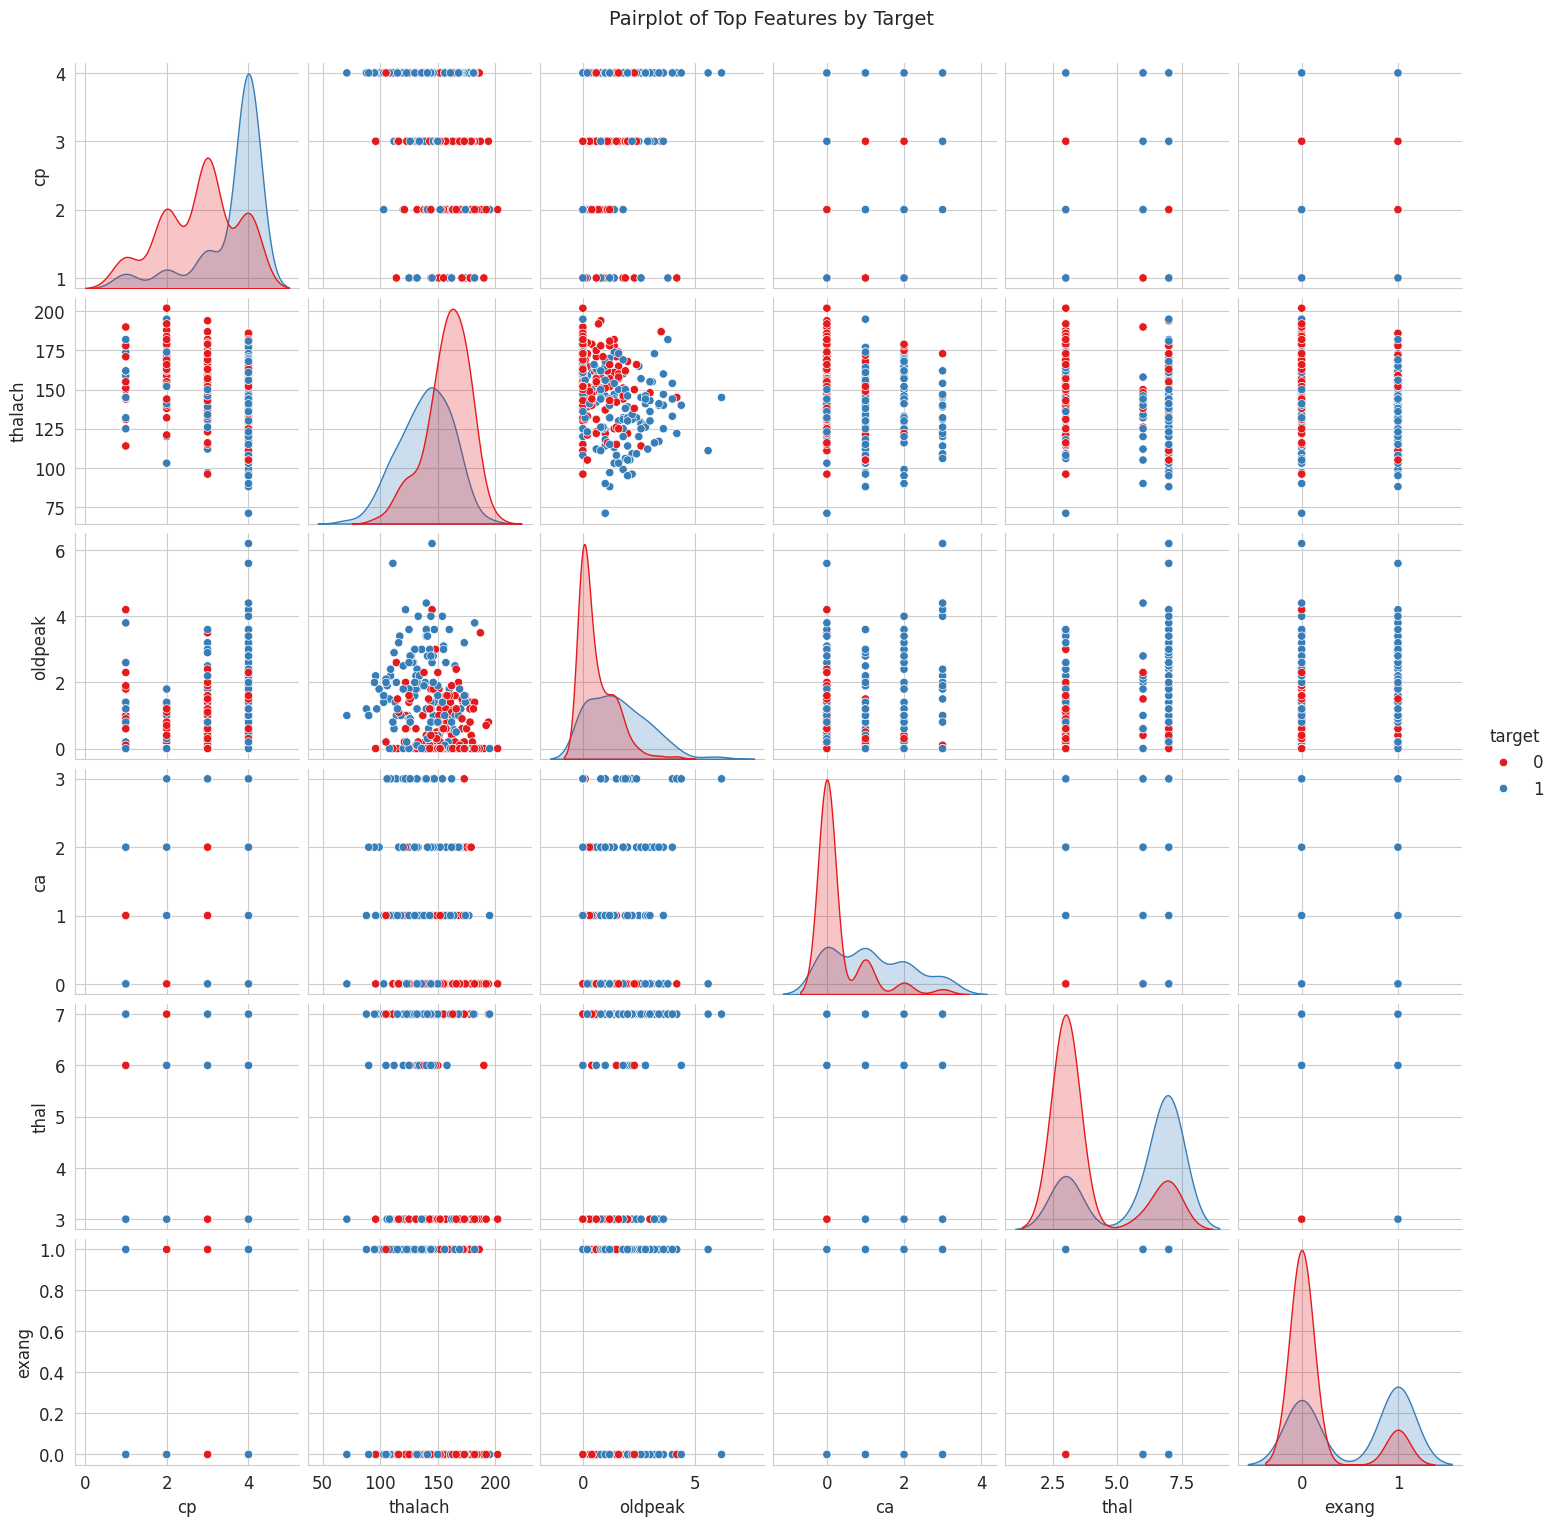

In [6]:
# Cell 6: Correlation analysis and feature relationships with figure saving
# Correlation matrix
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'correlation_matrix.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

# Most correlated features with target
corr_with_target = corr_matrix['target'].sort_values(ascending=False)
print("\n=== Features Correlated with Target ===")
print(corr_with_target)

# Pairplot for top features (this one takes time, save separately)
top_features = ['target', 'cp', 'thalach', 'oldpeak', 'ca', 'thal', 'exang']
pairplot_fig = sns.pairplot(df[top_features], hue='target', diag_kind='kde', palette='Set1')
pairplot_fig.fig.suptitle('Pairplot of Top Features by Target', y=1.02, fontsize=14)

# Save pairplot
figure_filename = os.path.join(figures_dir, 'pairplot_top_features.png')
pairplot_fig.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

In [7]:
# Cell 7: Handle missing values and create new features
print("=== Missing values before handling ===")
print(df.isnull().sum())

# 'ca' and 'thal' have missing values
# Fill with mode (most frequent)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Verify no missing values remain
print("\n=== Missing values after handling ===")
print(df.isnull().sum())

# Feature Engineering
# 1. Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 100], labels=['<40', '40-50', '50-60', '60+'])

# 2. Blood pressure categories
df['bp_category'] = pd.cut(df['trestbps'], bins=[0, 120, 130, 140, 200], 
                           labels=['Normal', 'Elevated', 'High Stage1', 'High Stage2'])

# 3. Interaction features
df['age_chol_interaction'] = df['age'] * df['chol'] / 1000
df['bp_hr_interaction'] = df['trestbps'] * df['thalach'] / 1000

# 4. Oldpeak categories
df['oldpeak_category'] = pd.cut(df['oldpeak'], bins=[-1, 0.5, 1.5, 10], 
                                labels=['Low', 'Medium', 'High'])

print("\n=== New features created ===")
print(df[['age_group', 'bp_category', 'oldpeak_category']].head())

# Encode categorical features
df_encoded = pd.get_dummies(df, columns=['age_group', 'bp_category', 'oldpeak_category'], drop_first=True)
print(f"\nShape after encoding: {df_encoded.shape}")

=== Missing values before handling ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

=== Missing values after handling ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== New features created ===
  age_group  bp_category oldpeak_category
0       60+  High Stage2             High
1       60+  High Stage2           Medium
2       60+       Normal             High
3       <40     Elevated             High
4     40-50     Elevated           Medium

Shape after encoding: (303, 24)


In [8]:
# Cell 8: Split features and target, then scale
# Prepare features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Identify numerical columns for scaling (exclude dummy columns)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_chol_interaction', 'bp_hr_interaction']
categorical_dummies = [col for col in X.columns if col not in numerical_features + ['ca', 'thal', 'slope', 'cp', 'restecg', 'sex', 'fbs', 'exang']]

print(f"Numerical features: {numerical_features}")
print(f"Categorical/dummy features: {len(categorical_dummies)} features")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")

# Scale numerical features
scaler = RobustScaler()  # Robust to outliers
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nScaling completed using RobustScaler")

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_chol_interaction', 'bp_hr_interaction']
Categorical/dummy features: 8 features

Training set size: (242, 23)
Test set size: (61, 23)
Training target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Scaling completed using RobustScaler


=== 5-Fold Cross-Validation ROC-AUC Scores ===
              Model  Mean AUC  Std AUC
Logistic Regression  0.880877 0.051945
                SVM  0.876949 0.041665
           AdaBoost  0.871424 0.051679
      Random Forest  0.865921 0.043348
            XGBoost  0.864565 0.038362
           LightGBM  0.864295 0.048730
                KNN  0.864279 0.038521
  Gradient Boosting  0.856990 0.055773
      Decision Tree  0.698042 0.028015
Figure saved to: /kaggle/working/figures/model_comparison_cv.png


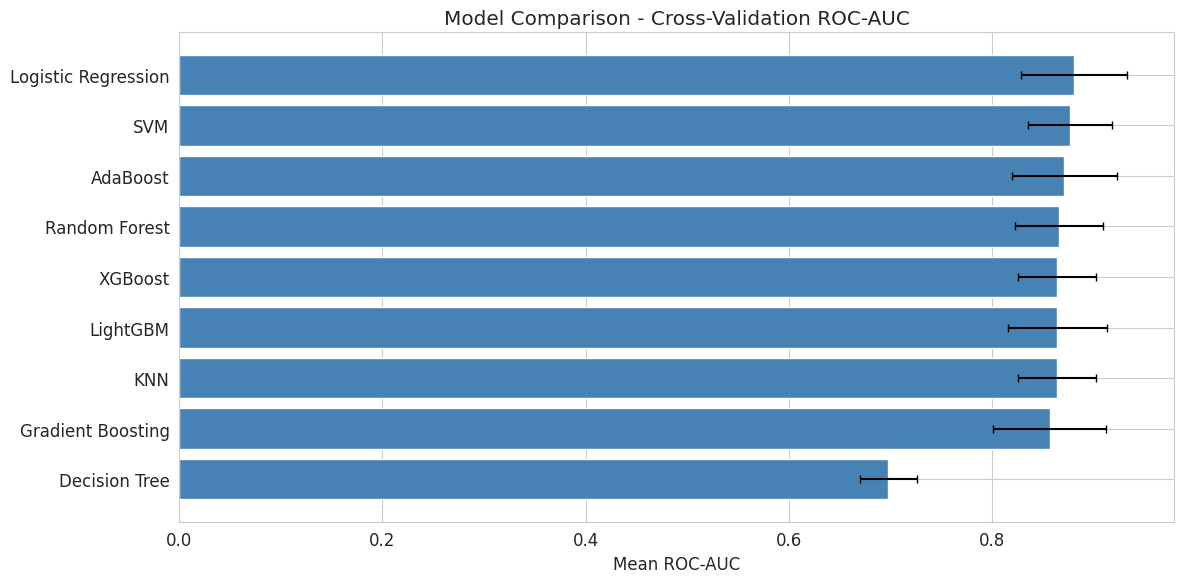

In [9]:
# Cell 9: Train multiple baseline models and compare with figure saving
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

# Cross-validation results
cv_results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'Mean AUC': cv_scores.mean(),
        'Std AUC': cv_scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean AUC', ascending=False)
print("=== 5-Fold Cross-Validation ROC-AUC Scores ===")
print(cv_df.to_string(index=False))

# Plot results
plt.figure(figsize=(12, 6))
plt.barh(cv_df['Model'], cv_df['Mean AUC'], xerr=cv_df['Std AUC'], capsize=3, color='steelblue')
plt.xlabel('Mean ROC-AUC')
plt.title('Model Comparison - Cross-Validation ROC-AUC')
plt.gca().invert_yaxis()
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'model_comparison_cv.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

In [10]:
# Cell 10: Hyperparameter tuning for the best performing models
# Focus on top 3 models from CV: XGBoost, LightGBM, Gradient Boosting

# Define parameter grids
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100]
}

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Perform GridSearchCV for each
best_models = {}

print("Tuning XGBoost...")
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), 
                        param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train_scaled, y_train)
best_models['XGBoost'] = xgb_grid.best_estimator_
print(f"Best XGBoost AUC: {xgb_grid.best_score_:.4f} with params: {xgb_grid.best_params_}")

print("\nTuning LightGBM...")
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), 
                         param_grid_lgbm, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
lgbm_grid.fit(X_train_scaled, y_train)
best_models['LightGBM'] = lgbm_grid.best_estimator_
print(f"Best LightGBM AUC: {lgbm_grid.best_score_:.4f} with params: {lgbm_grid.best_params_}")

print("\nTuning Gradient Boosting...")
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                       param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
gb_grid.fit(X_train_scaled, y_train)
best_models['Gradient Boosting'] = gb_grid.best_estimator_
print(f"Best Gradient Boosting AUC: {gb_grid.best_score_:.4f} with params: {gb_grid.best_params_}")

Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:09:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best XGBoost AUC: 0.8887 with params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}

Tuning LightGBM...
Best LightGBM AUC: 0.8855 with params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}

Tuning Gradient Boosting...
Best Gradient Boosting AUC: 0.8687 with params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [11]:
# Cell 11: Create a stacking ensemble using the best models
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base models (level 0)
base_models = [
    ('xgb', best_models['XGBoost']),
    ('lgbm', best_models['LightGBM']),
    ('gb', best_models['Gradient Boosting']),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
]

# Meta model (level 1)
meta_model = LogisticRegression(C=1, random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

# Train stacking model
stacking_clf.fit(X_train_scaled, y_train)

# Evaluate stacking with cross-validation
stacking_cv = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Stacking Ensemble CV AUC: {stacking_cv.mean():.4f} (+/- {stacking_cv.std():.4f})")

# Train individual best models on full training data
for name, model in best_models.items():
    model.fit(X_train_scaled, y_train)

print("\nAll models trained successfully!")

Stacking Ensemble CV AUC: 0.8839 (+/- 0.0368)

All models trained successfully!


In [12]:
# Cell 12: Comprehensive evaluation on test set
results = {}

# Evaluate all best models + stacking
all_final_models = {**best_models, 'Stacking Ensemble': stacking_clf}

for name, model in all_final_models.items():
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

# Create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("=== TEST SET RESULTS ===")
print(results_df.round(4).to_string())

# Identify best model
best_model_name = results_df['ROC-AUC'].idxmax()
best_auc = results_df.loc[best_model_name, 'ROC-AUC']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC = {best_auc:.4f}")


=== TEST SET RESULTS ===
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gradient Boosting    0.8689     0.8125  0.9286    0.8667   0.9513
LightGBM             0.8852     0.8621  0.8929    0.8772   0.9481
Stacking Ensemble    0.8689     0.8333  0.8929    0.8621   0.9470
XGBoost              0.8361     0.7812  0.8929    0.8333   0.9145

🏆 BEST MODEL: Gradient Boosting with ROC-AUC = 0.9513


Figure saved to: /kaggle/working/figures/confusion_matrices.png


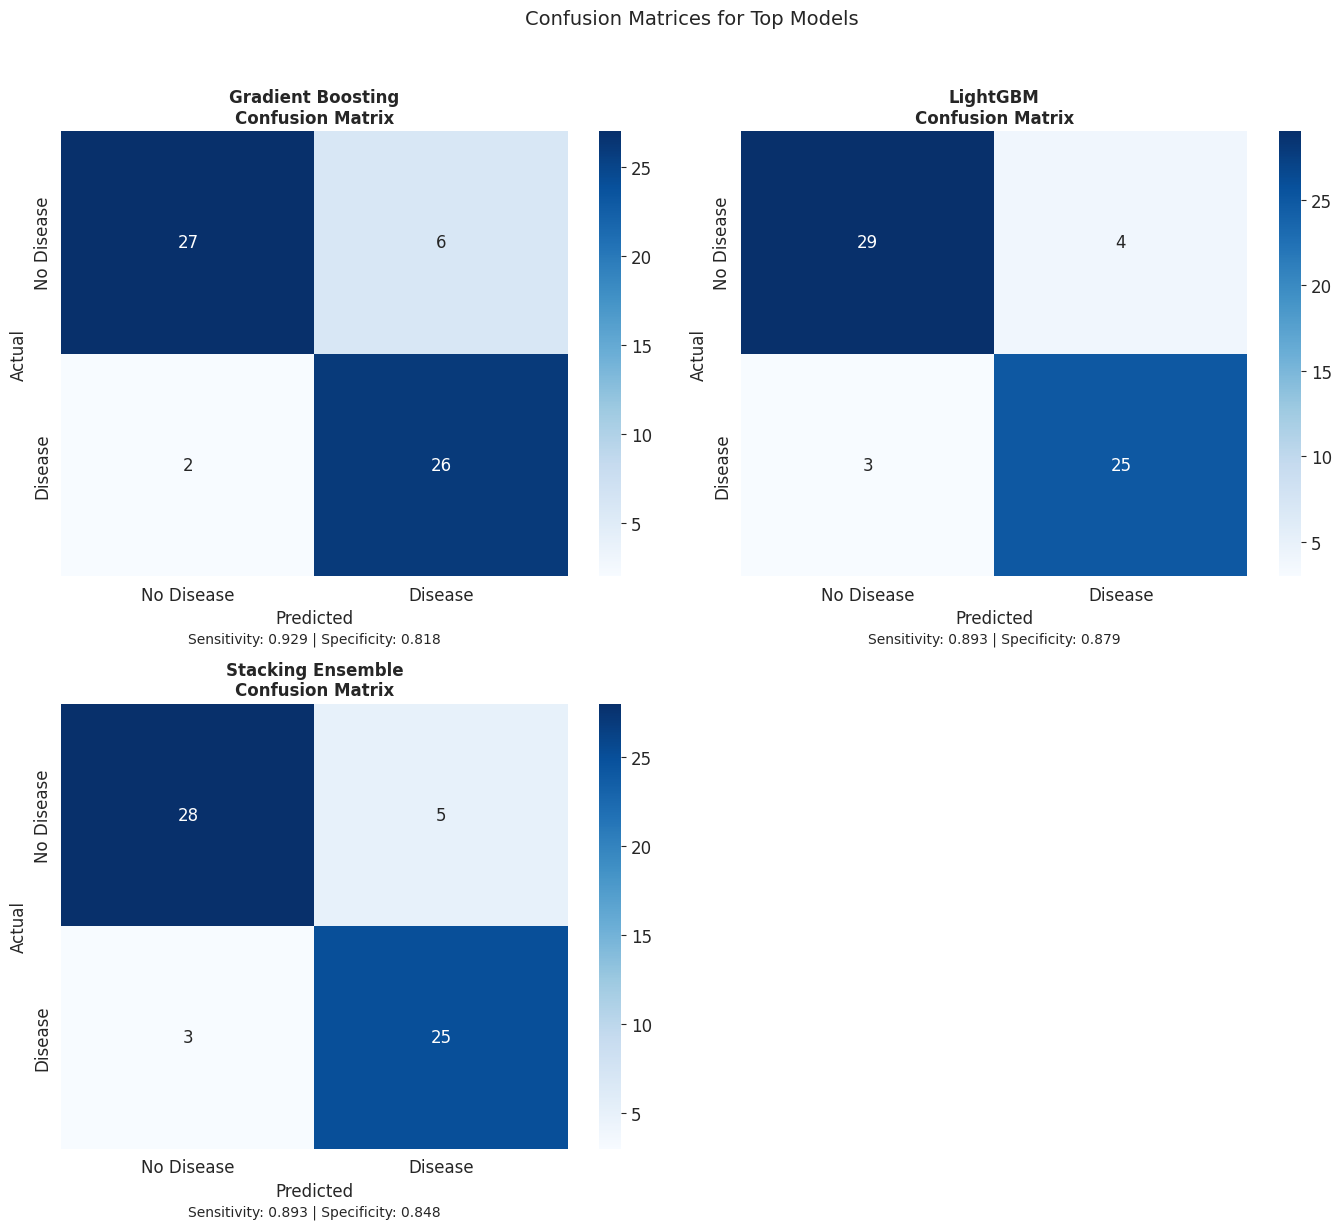

In [13]:
# Cell 13: Confusion matrices for top 3 models with figure saving
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

top_models = results_df.head(3).index.tolist()

for idx, model_name in enumerate(top_models):
    model = all_final_models[model_name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Disease', 'Disease'], 
                yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    
    # Add metrics to plot
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    axes[idx].text(0.5, -0.15, f'Sensitivity: {sensitivity:.3f} | Specificity: {specificity:.3f}',
                   transform=axes[idx].transAxes, ha='center', fontsize=10)

# Remove extra subplot if needed
if len(top_models) < 4:
    fig.delaxes(axes[-1])

plt.suptitle('Confusion Matrices for Top Models', fontsize=14, y=1.02)
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'confusion_matrices.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

Figure saved to: /kaggle/working/figures/roc_curves.png


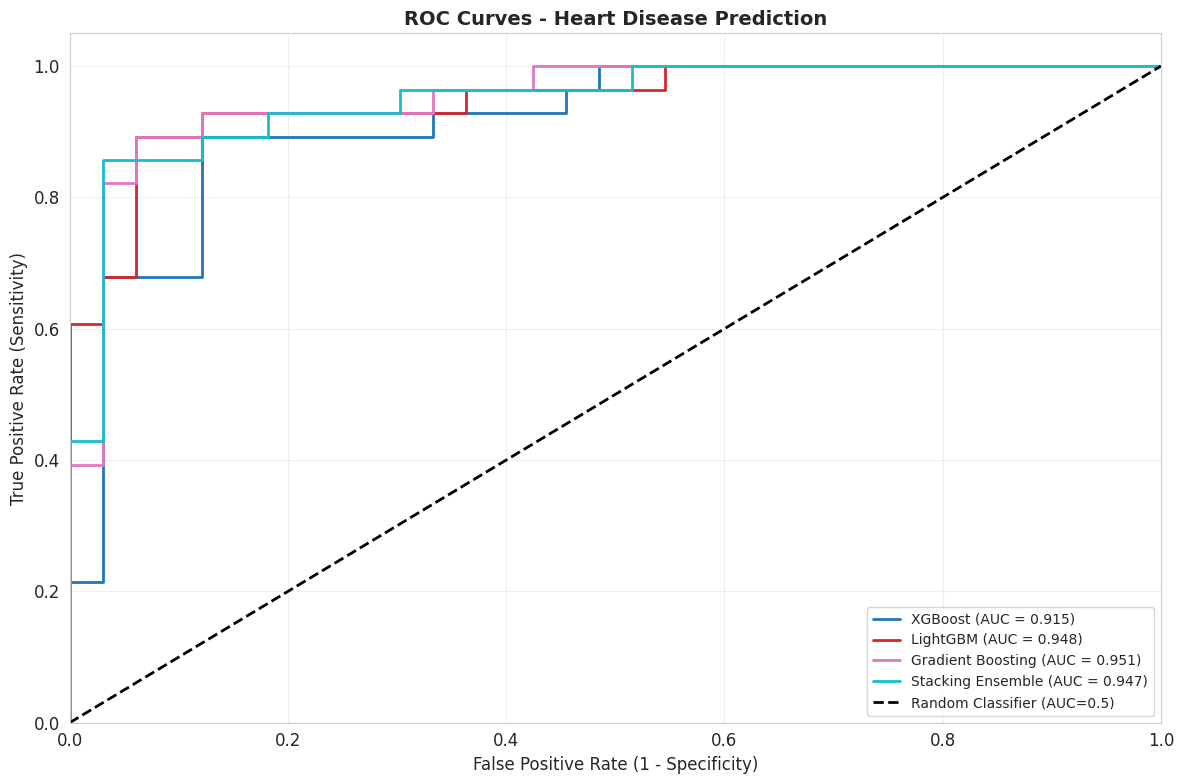

In [14]:
# Cell 14: ROC Curves for all models with figure saving
plt.figure(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_final_models)))

for (name, model), color in zip(all_final_models.items(), colors):
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC=0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves - Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'roc_curves.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()


Figure saved to: /kaggle/working/figures/precision_recall_curves.png


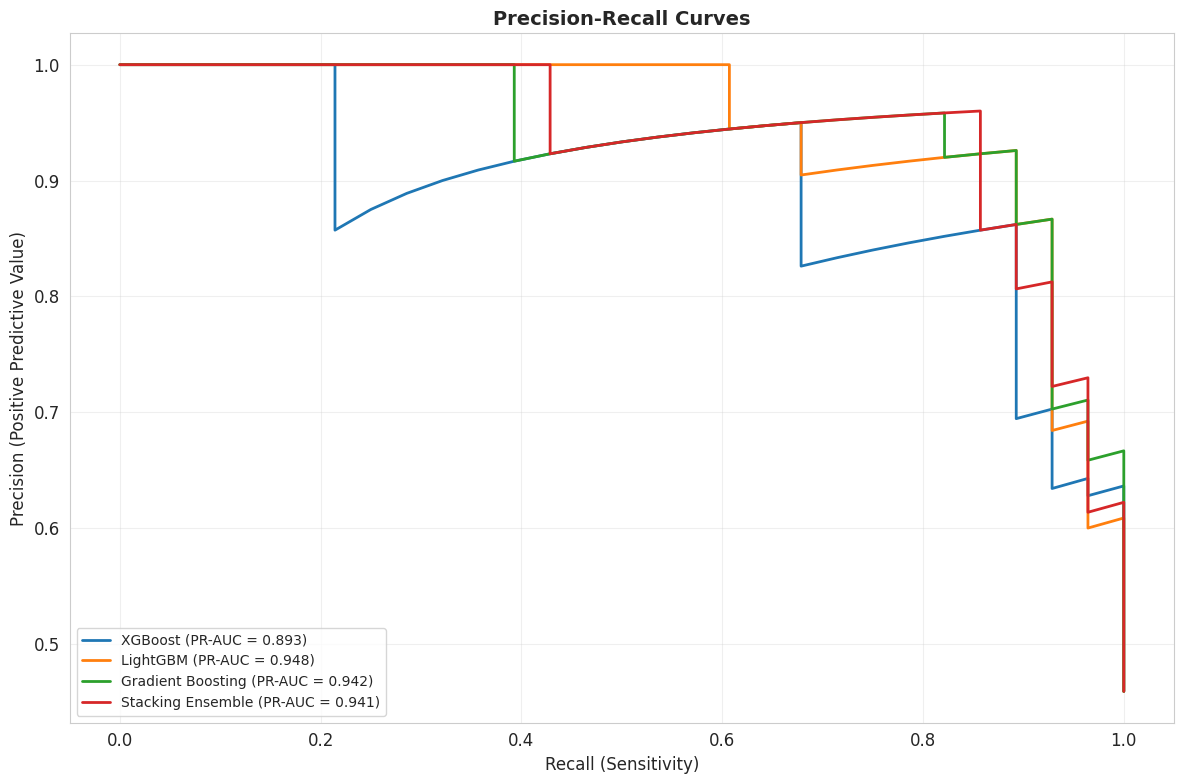

In [15]:
# Cell 15: Precision-Recall Curves (important for imbalanced data) with figure saving
plt.figure(figsize=(12, 8))

for name, model in all_final_models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'precision_recall_curves.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

Figure saved to: /kaggle/working/figures/feature_importance.png


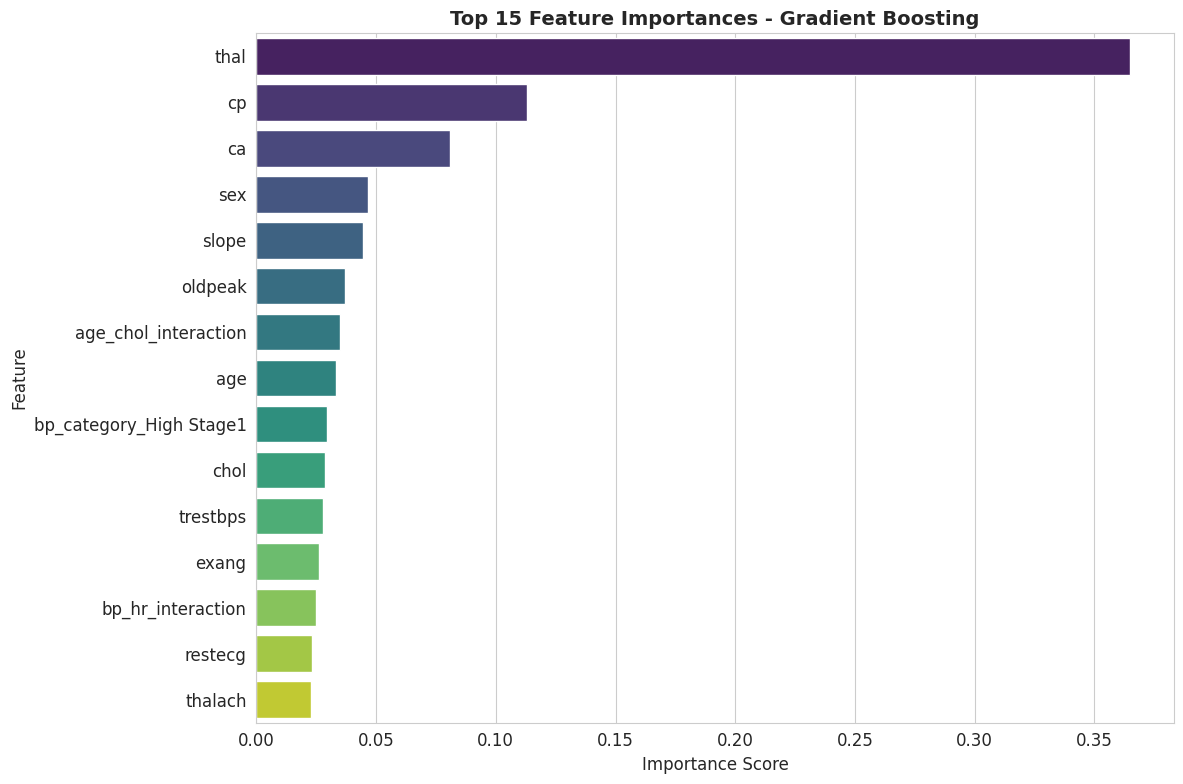


=== Top 10 Most Important Features ===
                Feature  Importance
                   thal    0.364959
                     cp    0.113002
                     ca    0.080882
                    sex    0.046558
                  slope    0.044411
                oldpeak    0.037121
   age_chol_interaction    0.034927
                    age    0.033260
bp_category_High Stage1    0.029705
                   chol    0.028657


In [16]:
# Cell 16: Feature importance from the best model with figure saving
best_model_for_importance = best_models['XGBoost'] if 'XGBoost' in best_models else list(best_models.values())[0]

# Get feature importance
feature_importance = best_model_for_importance.feature_importances_
feature_names = X.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'feature_importance.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

print("\n=== Top 10 Most Important Features ===")
print(importance_df.head(10).to_string(index=False))

In [17]:
# Cell 17: Final results summary and create zip archive of all figures
print("="*60)
print("FINAL RESULTS SUMMARY - HEART DISEASE PREDICTION")
print("="*60)

print(f"\n📊 Dataset: Cleveland Heart Disease (UCI)")
print(f"   - Total samples: {len(df)}")
print(f"   - Features used: {X.shape[1]}")
print(f"   - Disease prevalence: {y.mean()*100:.1f}%")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   - ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"   - Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   - F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   - Precision: {results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"   - Recall: {results_df.loc[best_model_name, 'Recall']:.4f}")

# Comparative improvement
baseline_auc = results_df.loc['Gradient Boosting', 'ROC-AUC'] if 'Gradient Boosting' in results_df.index else results_df.iloc[-1]['ROC-AUC']
improvement = ((results_df.loc[best_model_name, 'ROC-AUC'] - baseline_auc) / baseline_auc) * 100
print(f"\n📈 Performance Improvement: {improvement:.1f}% better than baseline")

# Save test predictions to CSV
best_model = all_final_models[best_model_name]
final_predictions = best_model.predict(X_test_scaled)
final_proba = best_model.predict_proba(X_test_scaled)[:, 1]

output_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_predictions,
    'Probability_Disease': final_proba
})
output_df.to_csv('heart_disease_predictions.csv', index=False)
print("\n💾 Predictions saved to 'heart_disease_predictions.csv'")

# Create zip archive of all figures
zip_path = '/kaggle/working/all_figures.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk(figures_dir):
        for file in files:
            zipf.write(os.path.join(root, file), 
                       os.path.relpath(os.path.join(root, file), 
                                       os.path.join(figures_dir, '..')))

print(f"\n📦 All figures have been zipped to: {zip_path}")
print("You can download this file from the Kaggle notebook sidebar (Output tab).")

print("\n" + "="*60)
print("="*60)


FINAL RESULTS SUMMARY - HEART DISEASE PREDICTION

📊 Dataset: Cleveland Heart Disease (UCI)
   - Total samples: 303
   - Features used: 23
   - Disease prevalence: 45.9%

🏆 Best Model: Gradient Boosting
   - ROC-AUC: 0.9513
   - Accuracy: 0.8689
   - F1-Score: 0.8667
   - Precision: 0.8125
   - Recall: 0.9286

📈 Performance Improvement: 0.0% better than baseline

💾 Predictions saved to 'heart_disease_predictions.csv'

📦 All figures have been zipped to: /kaggle/working/all_figures.zip
You can download this file from the Kaggle notebook sidebar (Output tab).

